In [2]:
!python -m pip install -r requirements.txt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sg

### 1. Obtención de la señal mental
#### 1.1. Señal a csv
##### 1.1.1 Señal simulada

In [3]:
# Parametros
frequency = 250
time = np.linspace(0, 5, 5 * frequency)

# Señal simulada
alpha_wave = 0.5 * np.sin(2 * np.pi * 10 * time)
beta_wave = 0.3 * np.sin(2 * np.pi * 20 * time)
noise = np.random.normal(0, 0.2, len(time))
eeg_signal = alpha_wave + beta_wave + noise

# Guardar datos en csv
df = pd.DataFrame({"tiempo": time, "eeg": eeg_signal})
df.to_csv("signal.csv", index=False)

##### 1.1.2. Señal descargada a formato esperado

In [4]:
#datos obtenidos de: https://figshare.com/articles/dataset/EEG_csv/25156508?file=44436671

file = "dwnld_signal.csv"
signal_csv = pd.read_csv(file)
signal_csv = signal_csv[signal_csv["Time"] != "Time"].astype("float64").drop_duplicates("Time")
signal_csv = signal_csv.sort_values("Time")
t = signal_csv["Time"].values
#señales con ruido externo reducido
signal1 = signal_csv["MV1"].values - signal_csv["MV2"].values
signal2 = signal_csv["MV3"].values - signal_csv["MV4"].values

#guardar resultados en signal.csv
#solo guardamos una de las señales y la centramos en 0
df = pd.DataFrame({"tiempo": t - min(t), "eeg": signal1 - signal1.mean()})
df.to_csv("signal.csv")

#### 1.2. Carga de la señal desde csv

In [5]:

signal_csv = pd.read_csv("signal.csv").astype("float64")
t = signal_csv["tiempo"].values
signal = signal_csv["eeg"].values

### 2. Visualizar la señal (amplitud vs tiempo)

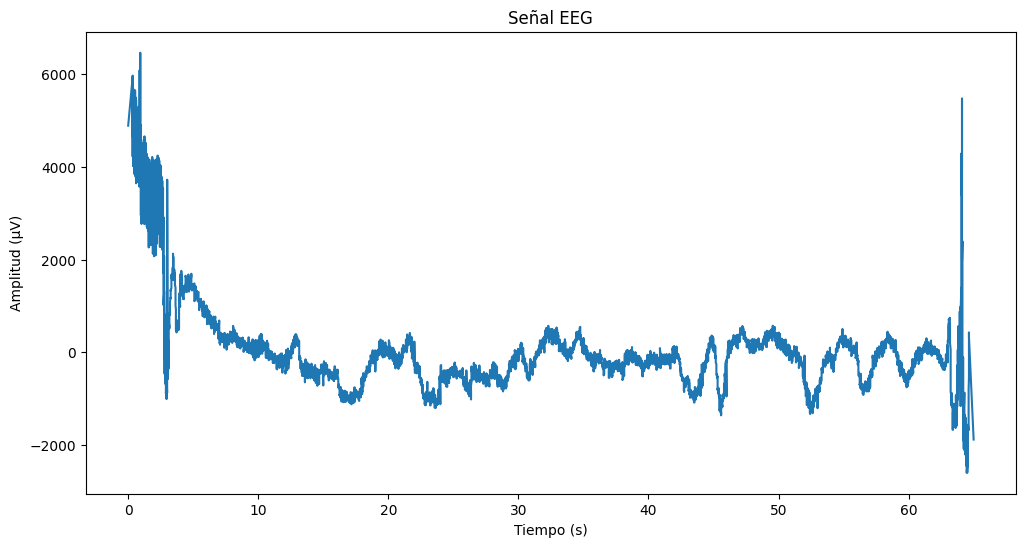

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label='Señal Cruda (EEG)')
plt.title("Señal EEG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.show()

### 3. Filtros de frecuencias

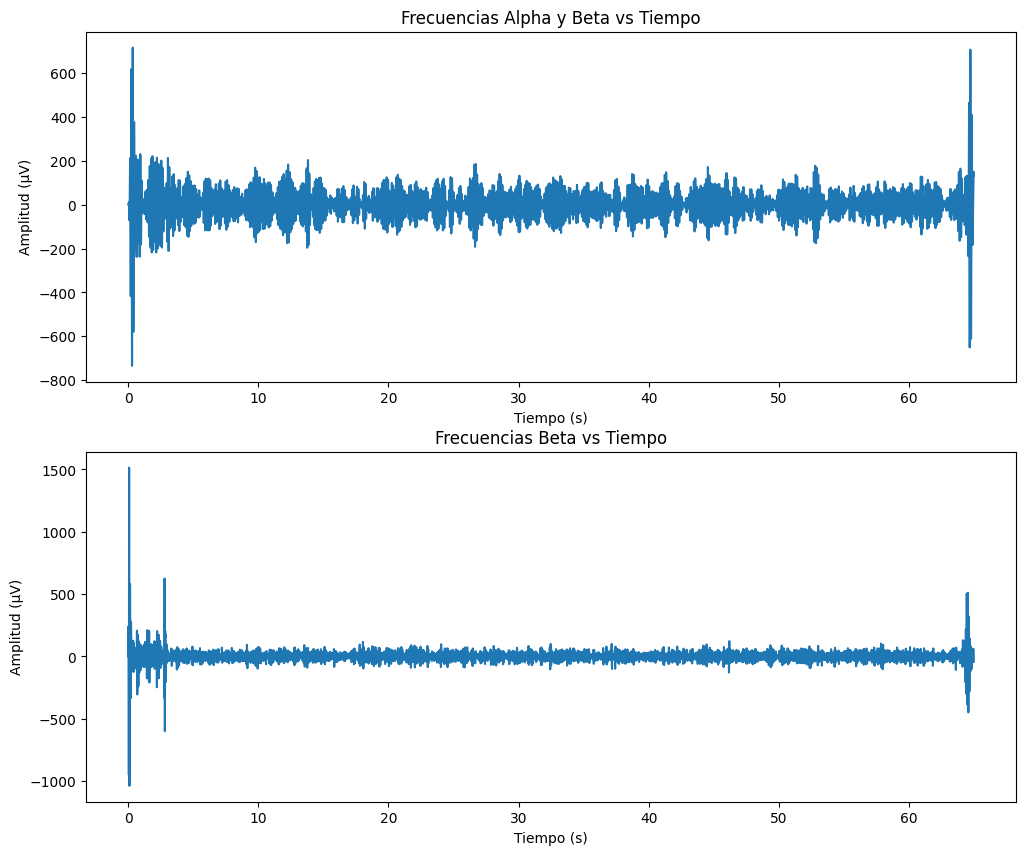

In [7]:
def freq_filter(data, lowcut, highcut, fs, order=5) -> np.ndarray:
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sg.butter(order, [low, high], btype='band')
    y = sg.lfilter(b, a, data)
    return y

freq = 250

#filtrar frecuencias 8-12 HZ
alpha_signal = freq_filter(signal, 8, 12, freq)

#filtrar frecuencias 12-30HZ
beta_signal = freq_filter(signal, 12, 30, freq)

t = np.linspace(0, max(t), len(signal))

# Gráfica frecuencias alpha 
plt.figure(figsize=(12, 10))
plt.subplot(2,1,1)
plt.plot(t, alpha_signal, label='Frecuencias Alpha')
plt.title("Frecuencias Alpha y Beta vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")

# Gráfica frecuencias beta 
plt.subplot(2,1,2)
plt.plot(t, beta_signal, label='Frecuencias Beta')
plt.title("Frecuencias Beta vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.show()

### 4. Indicador de activación

Text(0, 0.5, 'Amplitud (µV)')

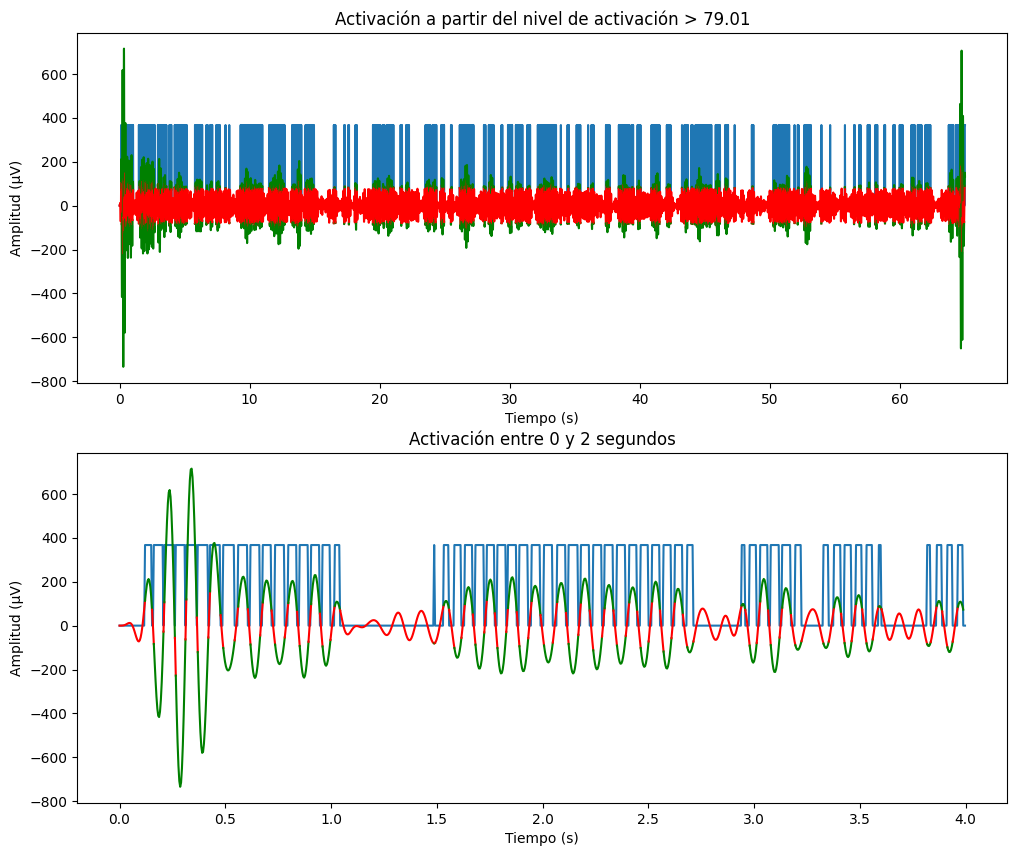

In [8]:
abs_alpha = np.abs(alpha_signal)
activation = abs_alpha.mean() * 1.5
activated = abs_alpha > activation
signal_activated = 1/2 * abs_alpha.max() * activated

act_separated:list[tuple[list[float],list[float], str]] = []
curr_act = not activated[0]
for time, alpha, is_act in zip(t, alpha_signal, activated):
    if curr_act != is_act:
        if len(act_separated) > 0:
            act_separated[-1][0].append(time)
            act_separated[-1][1].append(alpha)
        act_separated.append(([], [], "green" if is_act else "red"))
    act_separated[-1][0].append(time)
    act_separated[-1][1].append(alpha)
    curr_act = is_act


plt.figure(figsize=(12, 10))
plt.subplot(2,1,1)
plt.plot(t, signal_activated, label='Señal activación')
for s_t, s_a, c in act_separated:
    plt.plot(s_t, s_a, c=c)
plt.title(f"Activación a partir del nivel de activación > {activation:.2f}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.subplot(2,1,2)
max_s = 4
trunk = t < max_s
plt.plot(t[trunk], signal_activated[trunk], label='Señal activación')
for s_t, s_a, c in act_separated:
    if s_t[-1] >= max_s:
        break
    plt.plot(s_t, s_a, c=c)

plt.title(f"Activación entre 0 y 2 segundos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")